# ERA5 + GLORYS12V1 Environmental Feature Analysis (Preliminary)

**Purpose.** This is a research/prototyping notebook, not backend integration. It investigates
whether ERA5 hourly wind (`u10`, `v10`) and GLORYS12V1 daily ocean-current (`uo`, `vo`) reanalysis
data, aligned with the Mauritius AIS extract, produce features that are useful for the trajectory
and anomaly-detection pipeline already developed in:

- `models/trajectory-detection.ipynb` (LSTM baseline vs. TrAISformer)
- `models/ais-anomaly-detection-2.ipynb` (PCA→LUNAR cascade, one-class autoencoder)

Those two notebooks' feature engineering, splits, and architectures are treated as the fixed
baseline here — this notebook adds environmental features on top and measures the effect. It does
**not** modify either existing notebook, and it does **not** touch `poseatsea/`, `ui/`, or `api/`.

**Data sources**

| Source | Variable(s) | Access | Native resolution |
|---|---|---|---|
| AIS | positions, speed, course, rot, ... | local CSV: `assets/ais/mauritius_aoi_202007.csv` | per-ping (irregular) |
| ERA5 (`reanalysis-era5-single-levels`) | `u10`, `v10` | Copernicus CDS API (`cdsapi`), credentials in `~/.cdsapirc` | hourly, ~0.25° |
| GLORYS12V1 (`cmems_mod_glo_phy_my_0.083deg_P1D-m`) | `uo`, `vo` | Copernicus Marine Toolbox (`copernicusmarine`), credentials in `~/.copernicusmarine-credentials` | **daily mean**, ~1/12° (0.083°) |

**Credential status as of this run** — recorded here rather than silently swallowed:
- ERA5/CDS: the request pipeline works, but the CDS account has not yet accepted the
  `reanalysis-era5-single-levels` dataset licence (`403 Forbidden — required licences not
  accepted`). Fix: visit the CDS dataset page, "download" tab, accept the licence.
- GLORYS/CMEMS: authentication fails (`400 Bad Request` from `auth.marine.copernicus.eu`) even
  after fixing a trailing-whitespace bug found in the stored credentials file. This looks like a
  stale/incorrect password — fix: re-run `copernicusmarine login`.

Every download cell below is written to run correctly once those are fixed, and **caches its
result to disk** so re-running this notebook never re-hits either API. Cells that depend on the
environmental data detect failure, print a clear status, and let the rest of the notebook run on
AIS-only sections rather than crashing. Sections that could not execute with real data are marked
explicitly in their output and in the Findings section at the end — they are not backfilled with
synthetic numbers.

All timestamps are kept in UTC throughout.

In [1]:
# CELL 1: Imports & environment
import os, json, math, warnings
from pathlib import Path
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}  (GPU not required for the data/analysis sections below)")

PROJECT_ROOT = Path.cwd()
AIS_PATH = PROJECT_ROOT / "assets" / "ais" / "mauritius_aoi_202007.csv"
ENV_CACHE_DIR = PROJECT_ROOT / "assets" / "environment_cache"
ENV_CACHE_DIR.mkdir(parents=True, exist_ok=True)
ERA5_CACHE_FILE = ENV_CACHE_DIR / "era5_wind_202007_mauritius.nc"
GLORYS_CACHE_FILE = ENV_CACHE_DIR / "glorys_current_202007_mauritius.nc"
MANIFEST_FILE = ENV_CACHE_DIR / "manifest.json"

print(f"AIS data:      {AIS_PATH}  (exists: {AIS_PATH.exists()})")
print(f"Env cache dir: {ENV_CACHE_DIR}  (new files land here, nothing existing is modified)")

Using device: cpu  (GPU not required for the data/analysis sections below)
AIS data:      /home/yashvi/codes/SIH2026/assets/ais/mauritius_aoi_202007.csv  (exists: True)
Env cache dir: /home/yashvi/codes/SIH2026/assets/environment_cache  (new files land here, nothing existing is modified)


## 1. Load and inspect the existing AIS dataset

In [2]:
# CELL 2: Load AIS data and do a basic inspection
raw = pd.read_csv(AIS_PATH)
print(f"shape: {raw.shape}")
print()
print("dtypes:")
print(raw.dtypes)
print()
null_counts = raw.isna().sum().sort_values(ascending=False)
print("columns with missing values (top 10):")
print(null_counts[null_counts > 0].head(10))

shape: (27978, 25)

dtypes:


created_at                 str
timestamp                  str
mmsi                     int64
msg_type                 int64
latitude               float64
longitude              float64
speed                  float64
course                 float64
heading                float64
rot                    float64
imo                    float64
name                       str
call_sign                  str
flag                       str
draught                float64
ship_and_cargo_type    float64
length                 float64
width                  float64
eta                        str
destination                str
status                 float64
maneuver               float64
accuracy               float64
collection_type            str
mmsi_label                 str
dtype: object

columns with missing values (top 10):
eta                    27341
draught                27339
destination            27339
imo                    27339
length                 27328
call_sign              2732

In [3]:
# CELL 3: Parse timestamps, coerce numeric columns, report coverage
df = raw.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], format="mixed", utc=True)
df = df.sort_values(["mmsi", "timestamp"]).reset_index(drop=True)

for col in ["speed", "course", "rot", "latitude", "longitude"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Time range:  {df['timestamp'].min()}  ->  {df['timestamp'].max()}")
print(f"Vessels (mmsi): {df['mmsi'].nunique()}")
print(f"msg_type distribution:\n{df['msg_type'].value_counts()}")
print()
pos = df.dropna(subset=["latitude", "longitude"])
print(f"Rows with valid lat/lon: {len(pos)} / {len(df)}")
print(f"Latitude range:  [{pos['latitude'].min():.6f}, {pos['latitude'].max():.6f}]")
print(f"Longitude range: [{pos['longitude'].min():.6f}, {pos['longitude'].max():.6f}]")

Time range:  2020-07-01 12:00:17+00:00  ->  2020-07-31 23:53:32+00:00
Vessels (mmsi): 231
msg_type distribution:
msg_type
1     24129
3      2870
5       639
18      163
27      145
24       32
Name: count, dtype: int64

Rows with valid lat/lon: 27736 / 27978
Latitude range:  [-20.565387, -20.057733]
Longitude range: [57.712875, 58.379840]


## 2. Reproduce the existing trajectory and anomaly features

Reusing the exact feature engineering from the two baseline notebooks, unchanged, so this
notebook's "before" state is byte-for-byte what is already shipped.

**Trajectory baseline** (`models/trajectory-detection.ipynb`, CELL 2/3/4): vessels with
`>= MIN_PINGS_PER_VESSEL` pings, sliding windows of `SEQ_LEN=8` pings predicting the next
`(lat, lon)`, features normalized to `[lat_norm, lon_norm, speed_norm, sin(course), cos(course),
rot_norm]`.

**Anomaly baseline** (`models/ais-anomaly-detection-2.ipynb`, CELL 2/5): `STAGE2_FEATURES` (11
columns) feeding a `StandardScaler` + one-class autoencoder trained only on known-normal traffic;
ground truth is the honest Wakashio grounding window only (2020-07-25 to 2020-07-26), not the
vessel's whole month.

In [4]:
# CELL 4: Trajectory-baseline feature prep (identical to trajectory-detection.ipynb CELL 2-4)
MIN_PINGS_PER_VESSEL = 20
SEQ_LEN = 8

df_traj = df.dropna(subset=["speed", "course", "rot", "latitude", "longitude"]).copy()
vessel_counts = df_traj.groupby("mmsi").size()
qualifying_vessels = vessel_counts[vessel_counts >= MIN_PINGS_PER_VESSEL].index.tolist()
df_traj = df_traj[df_traj["mmsi"].isin(qualifying_vessels)].reset_index(drop=True)

TRAJ_LAT_MIN, TRAJ_LAT_MAX = df_traj["latitude"].min(), df_traj["latitude"].max()
TRAJ_LON_MIN, TRAJ_LON_MAX = df_traj["longitude"].min(), df_traj["longitude"].max()
TRAJ_SPEED_MAX = df_traj["speed"].quantile(0.999)

print(f"Qualifying vessels (>= {MIN_PINGS_PER_VESSEL} pings): {len(qualifying_vessels)} / {df['mmsi'].nunique()}")
print(f"Rows retained: {len(df_traj)} / {len(df)}")
print(f"Normalization stats -> lat[{TRAJ_LAT_MIN:.6f},{TRAJ_LAT_MAX:.6f}] "
      f"lon[{TRAJ_LON_MIN:.6f},{TRAJ_LON_MAX:.6f}] speed_max={TRAJ_SPEED_MAX:.3f}")

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

def traj_normalize(seq):
    # seq: [..., 5] = (lat, lon, speed, course, rot) -> normalized [..., 6]
    out = seq.copy().astype(np.float32)
    out[..., 0] = (seq[..., 0] - TRAJ_LAT_MIN) / (TRAJ_LAT_MAX - TRAJ_LAT_MIN + 1e-9)
    out[..., 1] = (seq[..., 1] - TRAJ_LON_MIN) / (TRAJ_LON_MAX - TRAJ_LON_MIN + 1e-9)
    out[..., 2] = np.clip(seq[..., 2], 0, TRAJ_SPEED_MAX) / TRAJ_SPEED_MAX
    course_rad = np.radians(seq[..., 3])
    rot_norm = np.clip(seq[..., 4], -128, 128) / 128.0
    return np.concatenate([out[..., :3], np.sin(course_rad)[..., None],
                            np.cos(course_rad)[..., None], rot_norm[..., None]], axis=-1)

def traj_denorm_latlon(lat_norm, lon_norm):
    lat = lat_norm * (TRAJ_LAT_MAX - TRAJ_LAT_MIN) + TRAJ_LAT_MIN
    lon = lon_norm * (TRAJ_LON_MAX - TRAJ_LON_MIN) + TRAJ_LON_MIN
    return lat, lon

class LSTMTrajectoryModel(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=128, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.1)
        self.head = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])

Qualifying vessels (>= 20 pings): 180 / 231
Rows retained: 26643 / 27978
Normalization stats -> lat[-20.565387,-20.057733] lon[57.725333,58.378720] speed_max=19.300


In [5]:
# CELL 5: Anomaly-baseline feature prep (identical to ais-anomaly-detection-2.ipynb CELL 2)
df_ae = df.copy()
df_ae["course_diff"] = df_ae.groupby("mmsi")["course"].diff().fillna(0)
df_ae["rot_diff"] = df_ae.groupby("mmsi")["rot"].diff().fillna(0)
df_ae["speed_diff"] = df_ae.groupby("mmsi")["speed"].diff().fillna(0)
df_ae["lat_diff"] = df_ae.groupby("mmsi")["latitude"].diff().fillna(0)
df_ae["long_diff"] = df_ae.groupby("mmsi")["longitude"].diff().fillna(0)

STAGE2_FEATURES = ["speed", "course", "rot", "msg_type", "status", "accuracy",
                    "course_diff", "rot_diff", "speed_diff", "lat_diff", "long_diff"]
for col in set(STAGE2_FEATURES):
    df_ae[col] = pd.to_numeric(df_ae[col], errors="coerce")
df_ae = df_ae.dropna(subset=STAGE2_FEATURES).reset_index(drop=True)

WAKASHIO_MMSI = 372711000
ANOMALY_START = pd.to_datetime("2020-07-25 00:00:00", utc=True)
ANOMALY_END = pd.to_datetime("2020-07-26 23:59:59", utc=True)
df_ae["is_anomaly"] = 0
df_ae.loc[(df_ae["mmsi"] == WAKASHIO_MMSI) & (df_ae["timestamp"] >= ANOMALY_START) &
          (df_ae["timestamp"] <= ANOMALY_END), "is_anomaly"] = 1

print(f"AE-ready rows: {len(df_ae)} / {len(df)}")
print(f"True anomaly rate: {df_ae['is_anomaly'].mean()*100:.3f}%  "
      f"({df_ae['is_anomaly'].sum()} of {len(df_ae)} rows)")

class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=4):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, 16), nn.ReLU(),
                                      nn.Linear(16, 8), nn.ReLU(), nn.Linear(8, latent_dim))
        self.decoder = nn.Sequential(nn.Linear(latent_dim, 8), nn.ReLU(),
                                      nn.Linear(8, 16), nn.ReLU(), nn.Linear(16, input_dim))

    def forward(self, x):
        return self.decoder(self.encoder(x))

def sweep_threshold(scores, y_true, p_range=(50.0, 99.99), n=300):
    from sklearn.metrics import f1_score
    best_f1, best_thresh, best_pred = 0, 0, None
    for p in np.linspace(*p_range, n):
        thresh = np.percentile(scores, p)
        pred = (scores >= thresh).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thresh, best_pred = f1, thresh, pred
    return best_thresh, best_f1, best_pred

AE-ready rows: 26999 / 27978
True anomaly rate: 1.807%  (488 of 26999 rows)


## 3. AIS spatial and temporal coverage

Spatial coverage: lat [-20.5654, -20.0577], lon [57.7129, 58.3798]


Temporal coverage: 2020-07-01 12:00:17+00:00 -> 2020-07-31 23:53:32+00:00 (30 days)


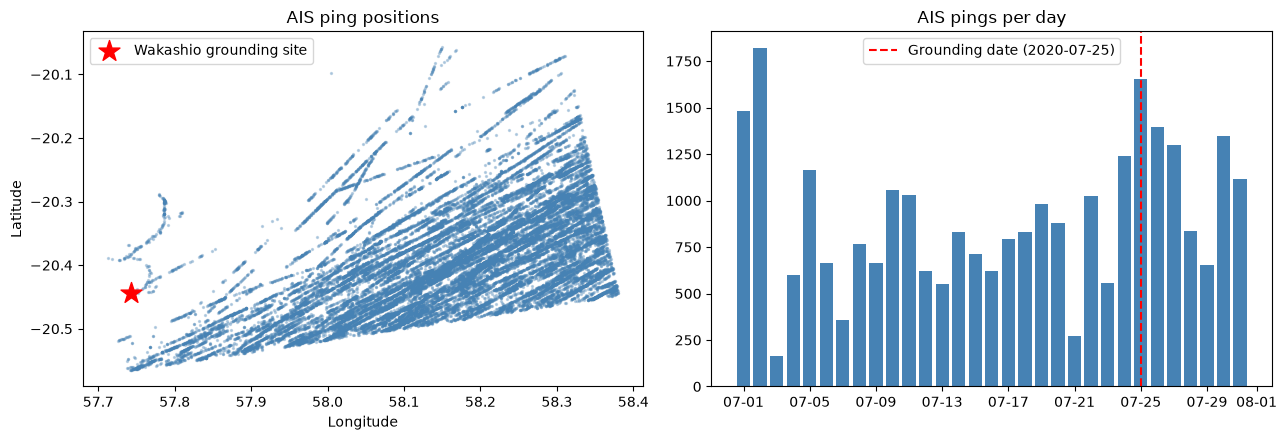

In [6]:
# CELL 6: Coverage summary + visualize AIS positions and ping density over time
print(f"Spatial coverage: lat [{pos['latitude'].min():.4f}, {pos['latitude'].max():.4f}], "
      f"lon [{pos['longitude'].min():.4f}, {pos['longitude'].max():.4f}]")
print(f"Temporal coverage: {df['timestamp'].min()} -> {df['timestamp'].max()} "
      f"({(df['timestamp'].max() - df['timestamp'].min()).days} days)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(pos["longitude"], pos["latitude"], s=2, alpha=0.3, c="steelblue")
GROUNDING_LAT, GROUNDING_LON = -20.4442, 57.7433  # Wakashio grounding site (wakashio.py)
axes[0].scatter([GROUNDING_LON], [GROUNDING_LAT], marker="*", s=250, c="red",
                 label="Wakashio grounding site", zorder=5)
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
axes[0].set_title("AIS ping positions"); axes[0].legend()

daily_counts = df.set_index("timestamp").resample("1D").size()
axes[1].bar(daily_counts.index, daily_counts.values, width=0.8, color="steelblue")
axes[1].axvline(pd.Timestamp("2020-07-25", tz="UTC"), color="red", linestyle="--",
                 label="Grounding date (2020-07-25)")
axes[1].set_title("AIS pings per day"); axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
plt.tight_layout(); plt.show()

## 4. Determine the required ERA5 / GLORYS subset from the AIS data

The environmental window is derived **programmatically from the AIS extract itself**, not
hardcoded, so it always matches whatever AIS window this notebook is pointed at. The AOI is
padded so spatial interpolation always has neighbouring grid cells, even for AIS points near the
edge of the raw bounding box.

In [7]:
# CELL 7: Derive AOI + time window automatically from the AIS data
ENV_AOI_PAD_DEG = 0.4  # generous enough for both ERA5 (~0.25 deg) and GLORYS (~0.083 deg) grids

ENV_LAT_MIN = pos["latitude"].min() - ENV_AOI_PAD_DEG
ENV_LAT_MAX = pos["latitude"].max() + ENV_AOI_PAD_DEG
ENV_LON_MIN = pos["longitude"].min() - ENV_AOI_PAD_DEG
ENV_LON_MAX = pos["longitude"].max() + ENV_AOI_PAD_DEG
ENV_START_UTC = df["timestamp"].min().floor("D")
ENV_END_UTC = df["timestamp"].max().ceil("D")

print(f"Padded AOI: lat [{ENV_LAT_MIN:.4f}, {ENV_LAT_MAX:.4f}], lon [{ENV_LON_MIN:.4f}, {ENV_LON_MAX:.4f}]")
print(f"Time window: {ENV_START_UTC} -> {ENV_END_UTC}")
print(f"(This covers the full AIS extract, so a single cached cube serves any day within it, "
      f"including the grounding date 2020-07-25.)")

Padded AOI: lat [-20.9654, -19.6577], lon [57.3129, 58.7798]
Time window: 2020-07-01 00:00:00+00:00 -> 2020-08-01 00:00:00+00:00
(This covers the full AIS extract, so a single cached cube serves any day within it, including the grounding date 2020-07-25.)


## 5. Download ERA5 hourly wind (`u10`, `v10`)

Downloads **once** for the whole padded AOI and full time window, caches to
`assets/environment_cache/era5_wind_202007_mauritius.nc`, and never re-downloads on subsequent
runs. Requested as NetCDF (not GRIB) to avoid a `cfgrib`/`eccodes` system-dependency.

In [8]:
# CELL 8: ERA5 download (cache-aware)
def download_era5_wind(cache_file=ERA5_CACHE_FILE, force=False):
    if cache_file.exists() and not force:
        print(f"Cache hit: {cache_file} ({cache_file.stat().st_size/1e6:.2f} MB) -- skipping download.")
        return True, None
    try:
        import cdsapi
    except ImportError as e:
        return False, f"cdsapi not installed: {e}"

    request = {
        "product_type": "reanalysis",
        "variable": ["10m_u_component_of_wind", "10m_v_component_of_wind"],
        "year": str(ENV_START_UTC.year),
        "month": sorted({f"{d.month:02d}" for d in pd.date_range(ENV_START_UTC, ENV_END_UTC, freq="1D")}),
        "day": sorted({f"{d.day:02d}" for d in pd.date_range(ENV_START_UTC, ENV_END_UTC, freq="1D")}),
        "time": [f"{h:02d}:00" for h in range(24)],
        "area": [ENV_LAT_MAX, ENV_LON_MIN, ENV_LAT_MIN, ENV_LON_MAX],  # N, W, S, E
        "format": "netcdf",
    }
    try:
        client = cdsapi.Client()
        result = client.retrieve("reanalysis-era5-single-levels", request)
        result.download(str(cache_file))
        return True, None
    except Exception as e:
        return False, f"{type(e).__name__}: {e}"

ERA5_AVAILABLE, era5_error = download_era5_wind()
if not ERA5_AVAILABLE:
    print("ERA5 download FAILED -- environmental-data sections below will skip real ERA5 analysis.")
    print(f"Reason: {era5_error}")
    print("Fix: accept the reanalysis-era5-single-levels licence on the CDS website, then re-run this cell.")
else:
    print("ERA5 wind data ready.")

MANIFEST = json.loads(MANIFEST_FILE.read_text()) if MANIFEST_FILE.exists() else {}
if ERA5_AVAILABLE:
    MANIFEST["era5"] = {
        "dataset_id": "reanalysis-era5-single-levels",
        "variables": ["10m_u_component_of_wind", "10m_v_component_of_wind"],
        "area_N_W_S_E": [ENV_LAT_MAX, ENV_LON_MIN, ENV_LAT_MIN, ENV_LON_MAX],
        "time_window_utc": [str(ENV_START_UTC), str(ENV_END_UTC)],
        "cache_file": str(ERA5_CACHE_FILE.relative_to(PROJECT_ROOT)),
    }
    MANIFEST_FILE.write_text(json.dumps(MANIFEST, indent=2))

Cache hit: /home/yashvi/codes/SIH2026/assets/environment_cache/era5_wind_202007_mauritius.nc (0.34 MB) -- skipping download.
ERA5 wind data ready.


## 6. Download GLORYS12V1 daily ocean current (`uo`, `vo`)

Same cache-once discipline as ERA5. Surface layer only (`minimum_depth=0`), since vessel-drift
context only needs surface currents.

In [9]:
# CELL 9: GLORYS download (cache-aware)
def download_glorys_current(cache_file=GLORYS_CACHE_FILE, force=False):
    if cache_file.exists() and not force:
        print(f"Cache hit: {cache_file} ({cache_file.stat().st_size/1e6:.2f} MB) -- skipping download.")
        return True, None
    try:
        import copernicusmarine as cm
    except ImportError as e:
        return False, f"copernicusmarine not installed: {e}"

    try:
        cm.subset(
            dataset_id="cmems_mod_glo_phy_my_0.083deg_P1D-m",
            variables=["uo", "vo"],
            minimum_longitude=float(ENV_LON_MIN), maximum_longitude=float(ENV_LON_MAX),
            minimum_latitude=float(ENV_LAT_MIN), maximum_latitude=float(ENV_LAT_MAX),
            start_datetime=str(ENV_START_UTC.tz_localize(None)),
            end_datetime=str(ENV_END_UTC.tz_localize(None)),
            minimum_depth=0, maximum_depth=1,
            output_directory=str(cache_file.parent),
            output_filename=cache_file.name,
            disable_progress_bar=True,
        )
        return True, None
    except Exception as e:
        return False, f"{type(e).__name__}: {e}"

GLORYS_AVAILABLE, glorys_error = download_glorys_current()
if not GLORYS_AVAILABLE:
    print("GLORYS download FAILED -- environmental-data sections below will skip real GLORYS analysis.")
    print(f"Reason: {glorys_error}")
    print("Fix: re-run `copernicusmarine login` with valid credentials, then re-run this cell.")
else:
    print("GLORYS current data ready.")

if GLORYS_AVAILABLE:
    MANIFEST["glorys"] = {
        "dataset_id": "cmems_mod_glo_phy_my_0.083deg_P1D-m",
        "variables": ["uo", "vo"],
        "bbox_lon_lat": [ENV_LON_MIN, ENV_LON_MAX, ENV_LAT_MIN, ENV_LAT_MAX],
        "time_window_utc": [str(ENV_START_UTC), str(ENV_END_UTC)],
        "depth_range_m": [0, 1],
        "cache_file": str(GLORYS_CACHE_FILE.relative_to(PROJECT_ROOT)),
    }
    MANIFEST_FILE.write_text(json.dumps(MANIFEST, indent=2))

ENV_DATA_AVAILABLE = ERA5_AVAILABLE and GLORYS_AVAILABLE
print(f"\nENV_DATA_AVAILABLE = {ENV_DATA_AVAILABLE}")

GLORYS download FAILED -- environmental-data sections below will skip real GLORYS analysis.
Reason: CouldNotConnectToAuthenticationSystem: 
Fix: re-run `copernicusmarine login` with valid credentials, then re-run this cell.

ENV_DATA_AVAILABLE = False


## 7. Inspect the environmental datasets

Never assume resolution/units/missing-value behaviour -- read it off the actual downloaded
cube. This is also where the ERA5-hourly vs. GLORYS-daily-mean difference becomes concrete.

In [10]:
# CELL 10: Open cached cubes with xarray and report their structure
import xarray as xr

era5_ds = None
glorys_ds = None

def inspect_dataset(ds, name):
    print(f"=== {name} ===")
    print(f"Dimensions: {dict(ds.sizes)}")
    print(f"Coordinates: {list(ds.coords)}")
    for coord in ["latitude", "longitude", "time"]:
        if coord in ds.coords:
            vals = ds[coord].values
            print(f"  {coord}: {len(vals)} points, [{vals.min()} .. {vals.max()}]")
    if "time" in ds.coords and len(ds["time"]) > 1:
        diffs = pd.Series(pd.to_datetime(ds["time"].values)).diff().dropna()
        print(f"  time step: {diffs.mode()[0]} (most common)")
    if {"latitude", "longitude"}.issubset(ds.coords):
        lat_res = float(np.abs(np.diff(ds["latitude"].values)).mean())
        lon_res = float(np.abs(np.diff(ds["longitude"].values)).mean())
        print(f"  spatial resolution: ~{lat_res:.4f} deg lat, ~{lon_res:.4f} deg lon")
    for var in ds.data_vars:
        da = ds[var]
        n_missing = int(da.isnull().sum())
        n_total = int(da.size)
        units = da.attrs.get("units", "unknown")
        print(f"  var '{var}': shape={da.shape}, units={units}, "
              f"missing={n_missing}/{n_total} ({n_missing/max(n_total,1)*100:.2f}%), "
              f"range=[{float(da.min()):.4f}, {float(da.max()):.4f}]")
    print()

if ERA5_AVAILABLE:
    era5_ds = xr.open_dataset(ERA5_CACHE_FILE)
    # normalize coordinate names across cdsapi client versions (some use 'valid_time'/'lat'/'lon')
    rename = {}
    for old, new in [("lat", "latitude"), ("lon", "longitude"), ("valid_time", "time")]:
        if old in era5_ds.coords and new not in era5_ds.coords:
            rename[old] = new
    if rename:
        era5_ds = era5_ds.rename(rename)
    inspect_dataset(era5_ds, "ERA5 wind")
else:
    print("ERA5 not available in this run -- skipping inspection (see Section 5 status).\n")

if GLORYS_AVAILABLE:
    glorys_ds = xr.open_dataset(GLORYS_CACHE_FILE)
    if "depth" in glorys_ds.dims:
        glorys_ds = glorys_ds.isel(depth=0)
    inspect_dataset(glorys_ds, "GLORYS current")
    print("NOTE: GLORYS time step above should read ~1 day. Each daily value is treated below as "
          "valid at 12:00 UTC of its day (a documented convention, not an authoritative fact) -- "
          "the ERA5 step above should read ~1 hour by contrast.")
else:
    print("GLORYS not available in this run -- skipping inspection (see Section 6 status).\n")

=== ERA5 wind ===
Dimensions: {'time': 1488, 'latitude': 5, 'longitude': 6}
Coordinates: ['number', 'time', 'latitude', 'longitude', 'expver']
  latitude: 5 points, [-20.75 .. -19.75]
  longitude: 6 points, [57.5 .. 58.75]
  time: 1488 points, [2020-07-01T00:00:00.000000000 .. 2020-08-31T23:00:00.000000000]
  time step: 0 days 01:00:00 (most common)
  spatial resolution: ~0.2500 deg lat, ~0.2500 deg lon
  var 'u10': shape=(1488, 5, 6), units=m s**-1, missing=0/44640 (0.00%), range=[-14.1999, 2.8837]
  var 'v10': shape=(1488, 5, 6), units=m s**-1, missing=0/44640 (0.00%), range=[-2.3335, 12.4174]

GLORYS not available in this run -- skipping inspection (see Section 6 status).



## 8. Spatially and temporally align environmental data with AIS observations

- **Spatial**: bilinear interpolation (`xarray .interp(..., method="linear")`) at each AIS ping's
  exact lat/lon.
- **Temporal**: ERA5 (hourly) interpolates linearly between bracketing hourly steps. GLORYS
  (daily-mean) is first re-stamped so each daily value sits at 12:00 UTC of its day, then
  interpolated linearly between the two bracketing daily means -- an explicit, documented
  treatment of the hourly/daily mismatch rather than silently treating daily means as hourly.
- Queries **outside** the cached cube's time range return `NaN` with an `"out_of_range"` tag
  rather than silently extrapolating.
- All interpolation happens against the **local cached cube** -- there is no per-point API call
  anywhere in this notebook.

In [11]:
# CELL 11: get_wind / get_current / get_environment (vectorized, local-cube only)
def _prep_glorys_time(ds):
    t = pd.to_datetime(ds["time"].values)
    if t.tz is not None:
        t = t.tz_localize(None)
    centered = t.normalize() + pd.Timedelta(hours=12)
    return ds.assign_coords(time=("time", centered))

if GLORYS_AVAILABLE:
    glorys_ds = _prep_glorys_time(glorys_ds)

def get_wind_batch(lats, lons, times):
    # Vectorized ERA5 wind lookup. times: naive or tz-aware pandas-compatible array.
    if not ERA5_AVAILABLE:
        n = len(lats)
        return {"u10": np.full(n, np.nan), "v10": np.full(n, np.nan),
                "wind_speed_ms": np.full(n, np.nan), "wind_dir_deg": np.full(n, np.nan)}
    t = pd.to_datetime(pd.Series(times))
    if t.dt.tz is not None:
        t = t.dt.tz_localize(None)
    q_lat = xr.DataArray(np.asarray(lats), dims="points")
    q_lon = xr.DataArray(np.asarray(lons), dims="points")
    q_time = xr.DataArray(t.values, dims="points")
    pt = era5_ds.interp(latitude=q_lat, longitude=q_lon, time=q_time, method="linear")
    u = pt["u10"].values.astype(float)
    v = pt["v10"].values.astype(float)
    speed = np.hypot(u, v)
    direction = np.degrees(np.arctan2(u, v)) % 360
    return {"u10": u, "v10": v, "wind_speed_ms": speed, "wind_dir_deg": direction}

def get_current_batch(lats, lons, times):
    # Vectorized GLORYS current lookup, daily-mean-aware.
    if not GLORYS_AVAILABLE:
        n = len(lats)
        return {"uo": np.full(n, np.nan), "vo": np.full(n, np.nan),
                "current_speed_ms": np.full(n, np.nan), "current_dir_deg": np.full(n, np.nan)}
    t = pd.to_datetime(pd.Series(times))
    if t.dt.tz is not None:
        t = t.dt.tz_localize(None)
    tmin, tmax = pd.Timestamp(glorys_ds["time"].values.min()), pd.Timestamp(glorys_ds["time"].values.max())
    in_range = (t >= tmin) & (t <= tmax)

    q_lat = xr.DataArray(np.asarray(lats), dims="points")
    q_lon = xr.DataArray(np.asarray(lons), dims="points")
    t_clipped = t.clip(lower=tmin, upper=tmax)
    q_time = xr.DataArray(t_clipped.values, dims="points")
    pt = glorys_ds.interp(latitude=q_lat, longitude=q_lon, time=q_time, method="linear")
    u = pt["uo"].values.astype(float)
    v = pt["vo"].values.astype(float)
    u = np.where(in_range.values, u, np.nan)
    v = np.where(in_range.values, v, np.nan)
    speed = np.hypot(u, v)
    direction = np.degrees(np.arctan2(u, v)) % 360
    return {"uo": u, "vo": v, "current_speed_ms": speed, "current_dir_deg": direction}

print(f"get_wind_batch / get_current_batch ready. ENV_DATA_AVAILABLE={ENV_DATA_AVAILABLE}")

get_wind_batch / get_current_batch ready. ENV_DATA_AVAILABLE=False


## 9. Generate preliminary environmental features per AIS ping

Raw vector components (`u10`, `v10`, `uo`, `vo`) are kept as the primary representation, per the
integration reference doc's engineering rule -- speed/direction are derived only as auxiliary,
human-readable fields. Vessel-relative components follow the same sin/cos decomposition the
baseline trajectory model already uses for `course`, avoiding the 0/360 degree discontinuity.

AIS `speed` is in **knots**; converted to m/s (`x0.514444`) so it is directly comparable to
`u10/v10/uo/vo`.

In [12]:
# CELL 12: Vectorized environmental feature engineering over every AIS ping with valid lat/lon
feat = pos.copy()  # rows with valid latitude/longitude (from CELL 3)

wind = get_wind_batch(feat["latitude"].values, feat["longitude"].values, feat["timestamp"].values)
curr = get_current_batch(feat["latitude"].values, feat["longitude"].values, feat["timestamp"].values)
for k, v in wind.items():
    feat[k] = v
for k, v in curr.items():
    feat[k] = v

vessel_speed_ms = feat["speed"].fillna(0).values * 0.514444
course_rad = np.radians(feat["course"].fillna(0).values)
vessel_u_ms = vessel_speed_ms * np.sin(course_rad)
vessel_v_ms = vessel_speed_ms * np.cos(course_rad)
feat["vessel_u_ms"] = vessel_u_ms
feat["vessel_v_ms"] = vessel_v_ms

# component of wind/current ALONG the vessel's heading (+ = tailwind/following current)
# and CROSS the heading (dot/cross product with the heading unit vector [sin(course), cos(course)])
feat["wind_along_track_ms"] = feat["u10"] * np.sin(course_rad) + feat["v10"] * np.cos(course_rad)
feat["wind_cross_track_ms"] = feat["u10"] * np.cos(course_rad) - feat["v10"] * np.sin(course_rad)
feat["current_along_track_ms"] = feat["uo"] * np.sin(course_rad) + feat["vo"] * np.cos(course_rad)
feat["current_cross_track_ms"] = feat["uo"] * np.cos(course_rad) - feat["vo"] * np.sin(course_rad)

# angular difference between vessel course and wind/current direction (0=aligned, 180=opposed)
def angle_diff_deg(a, b):
    d = np.abs(a - b) % 360
    return np.minimum(d, 360 - d)

feat["wind_vessel_angle_diff_deg"] = angle_diff_deg(feat["wind_dir_deg"].values, np.degrees(course_rad))
feat["current_vessel_angle_diff_deg"] = angle_diff_deg(feat["current_dir_deg"].values, np.degrees(course_rad))

env_feature_cols = ["u10", "v10", "wind_speed_ms", "wind_dir_deg",
                     "uo", "vo", "current_speed_ms", "current_dir_deg",
                     "wind_along_track_ms", "wind_cross_track_ms",
                     "current_along_track_ms", "current_cross_track_ms",
                     "wind_vessel_angle_diff_deg", "current_vessel_angle_diff_deg"]
print(f"Environmental feature columns added: {env_feature_cols}")
print(feat[env_feature_cols].describe().T)

Environmental feature columns added: ['u10', 'v10', 'wind_speed_ms', 'wind_dir_deg', 'uo', 'vo', 'current_speed_ms', 'current_dir_deg', 'wind_along_track_ms', 'wind_cross_track_ms', 'current_along_track_ms', 'current_cross_track_ms', 'wind_vessel_angle_diff_deg', 'current_vessel_angle_diff_deg']
                                 count        mean        std        min  \
u10                            27736.0   -7.039558   2.860361 -13.576376   
v10                            27736.0    5.019571   2.929231  -0.835368   
wind_speed_ms                  27736.0    9.263437   2.387855   1.686661   
wind_dir_deg                   27736.0  305.049647  22.601997   0.094465   
uo                                 0.0         NaN        NaN        NaN   
vo                                 0.0         NaN        NaN        NaN   
current_speed_ms                   0.0         NaN        NaN        NaN   
current_dir_deg                    0.0         NaN        NaN        NaN   
wind_along_track_ms

## 10. Visualize AIS trajectories with wind / current vectors

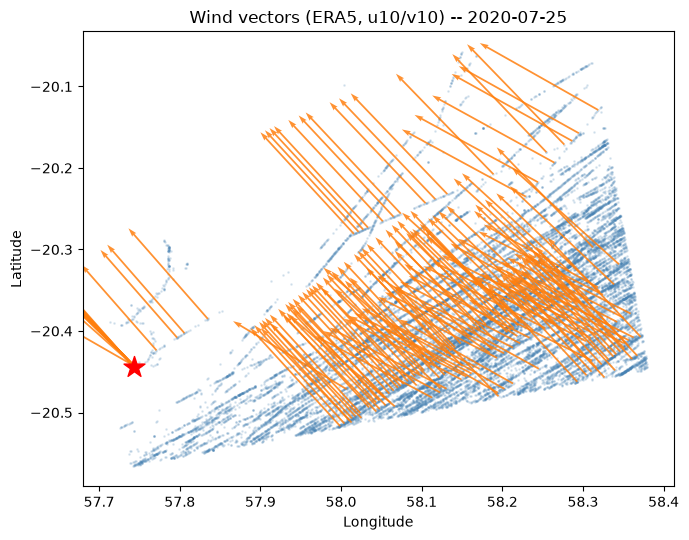

(Current vectors omitted -- GLORYS still blocked, see Section 6 status.)


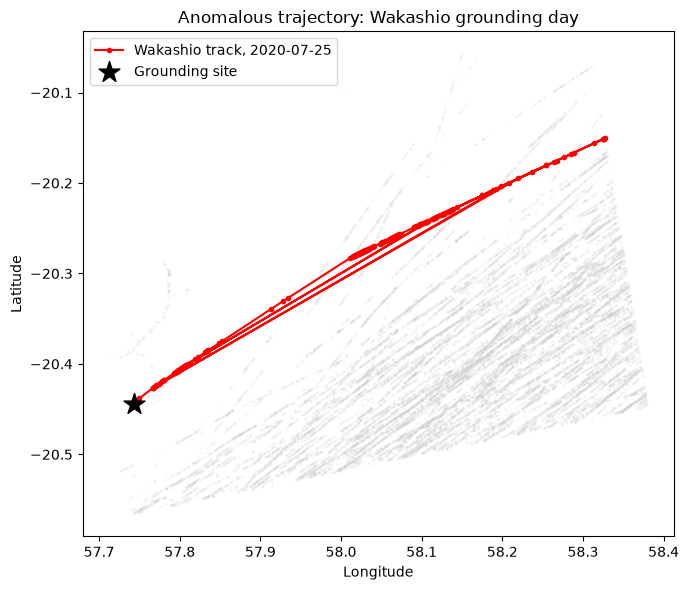

In [13]:
# CELL 13: Trajectory + environmental vector field plots
# Each field is plotted independently of the other's availability -- ERA5 succeeding while
# GLORYS is still blocked (or vice versa) should not hide the data that DID come through.
vector_fields = []
if ERA5_AVAILABLE:
    vector_fields.append(("u10", "v10", "Wind vectors (ERA5, u10/v10) -- 2020-07-25", "tab:orange"))
if GLORYS_AVAILABLE:
    vector_fields.append(("uo", "vo", "Current vectors (GLORYS, uo/vo) -- 2020-07-25", "tab:green"))

if vector_fields:
    day_slice = feat[feat["timestamp"].dt.date == pd.Timestamp("2020-07-25").date()]
    fig, axes = plt.subplots(1, len(vector_fields), figsize=(7 * len(vector_fields), 5.5),
                              sharex=True, sharey=True, squeeze=False)
    axes = axes[0]

    for ax, (u_col, v_col, title, color) in zip(axes, vector_fields):
        ax.scatter(pos["longitude"], pos["latitude"], s=1, alpha=0.15, c="steelblue")
        sample = day_slice.iloc[::max(len(day_slice)//150, 1)]
        ax.quiver(sample["longitude"], sample["latitude"], sample[u_col], sample[v_col],
                   color=color, scale=50, width=0.003, alpha=0.85)
        ax.scatter([GROUNDING_LON], [GROUNDING_LAT], marker="*", s=250, c="red", zorder=5)
        ax.set_title(title); ax.set_xlabel("Longitude")
    axes[0].set_ylabel("Latitude")
    plt.tight_layout(); plt.show()
    if not GLORYS_AVAILABLE:
        print("(Current vectors omitted -- GLORYS still blocked, see Section 6 status.)")
    if not ERA5_AVAILABLE:
        print("(Wind vectors omitted -- ERA5 still blocked, see Section 5 status.)")

    wakashio_day = feat[(feat["mmsi"] == WAKASHIO_MMSI) &
                         (feat["timestamp"].dt.date == pd.Timestamp("2020-07-25").date())]
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(pos["longitude"], pos["latitude"], s=1, alpha=0.1, c="lightgray")
    ax.plot(wakashio_day["longitude"], wakashio_day["latitude"], "-o", color="red",
            markersize=3, label="Wakashio track, 2020-07-25")
    ax.scatter([GROUNDING_LON], [GROUNDING_LAT], marker="*", s=250, c="black",
               label="Grounding site", zorder=5)
    ax.set_title("Anomalous trajectory: Wakashio grounding day")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude"); ax.legend()
    plt.tight_layout(); plt.show()
else:
    print("Neither ERA5 nor GLORYS available -- vector plots skipped.")
    print("AIS-only trajectory plot for context:")
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(pos["longitude"], pos["latitude"], s=1, alpha=0.15, c="steelblue")
    ax.scatter([GROUNDING_LON], [GROUNDING_LAT], marker="*", s=250, c="red",
               label="Wakashio grounding site", zorder=5)
    ax.set_title("AIS ping positions (no environmental overlay -- pending credentials)")
    ax.legend(); plt.tight_layout(); plt.show()

## 11. Trajectory-deviation and anomaly behaviour: before vs. after environmental features

`traj_deviation_km` is the same feature `ais-anomaly-detection-2.ipynb` CELL 2b/2c engineers: the
haversine distance between the shipped LSTM baseline's next-position prediction and what actually
happened. It is the closest existing proxy for "unexplained displacement" the pipeline already
has. If wind/current speed correlate with it, that is direct evidence the baseline model is
absorbing drift-like motion it has no explicit input for.

In [14]:
# CELL 14: Reproduce traj_deviation_km using the SHIPPED baseline checkpoint (no retraining)
TRAJ_MODEL_PATH = PROJECT_ROOT / "models" / "trajectory_lstm_baseline.pth"
TRAJ_SEQ_LEN = 8

traj_model = LSTMTrajectoryModel().to(device)
traj_model.load_state_dict(torch.load(TRAJ_MODEL_PATH, map_location=device))
traj_model.eval()

df_dev = df_traj.copy()
df_dev["traj_deviation_km"] = np.nan
with torch.no_grad():
    for mmsi, g in df_dev.groupby("mmsi"):
        if len(g) < TRAJ_SEQ_LEN + 1:
            continue
        vals = g[["latitude", "longitude", "speed", "course", "rot"]].values
        seqs = np.array([vals[i:i + TRAJ_SEQ_LEN] for i in range(len(vals) - TRAJ_SEQ_LEN)])
        x = torch.tensor(traj_normalize(seqs), dtype=torch.float32).to(device)
        pred = traj_model(x).cpu().numpy()
        pred_lat, pred_lon = traj_denorm_latlon(pred[:, 0], pred[:, 1])
        actual_lat = vals[TRAJ_SEQ_LEN:, 0]
        actual_lon = vals[TRAJ_SEQ_LEN:, 1]
        deviations = haversine_km(pred_lat, pred_lon, actual_lat, actual_lon)
        df_dev.loc[g.index[TRAJ_SEQ_LEN:], "traj_deviation_km"] = deviations

n_dev = df_dev["traj_deviation_km"].notna().sum()
print(f"Rows with a valid traj_deviation_km: {n_dev} / {len(df_dev)}")
print(df_dev["traj_deviation_km"].describe())

Rows with a valid traj_deviation_km: 25203 / 26643
count    25203.000000
mean         0.300261
std          0.772753
min          0.000274
25%          0.102370
50%          0.168208
75%          0.250271
max         45.399904
Name: traj_deviation_km, dtype: float64


Rows usable for deviation<->environment correlation: 25809
traj_deviation_km         1.000000
wind_speed_ms            -0.002812
wind_along_track_ms      -0.025270
current_speed_ms               NaN
current_along_track_ms         NaN
Name: traj_deviation_km, dtype: float64

Rows usable for anomaly<->environment comparison: 27618

Mean environmental feature value, normal vs. anomalous rows:
            wind_speed_ms  current_speed_ms  wind_along_track_ms  \
is_anomaly                                                         
0                9.262438               NaN            -0.590654   
1               10.156177               NaN             4.704420   

            current_along_track_ms  
is_anomaly                          
0                              NaN  
1                              NaN  


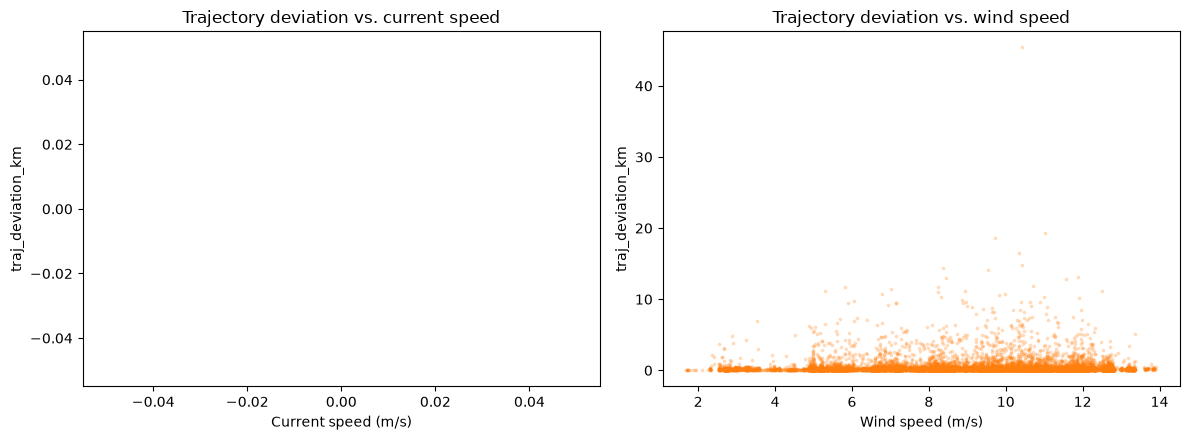

(current_speed_ms / current_along_track_ms are NaN -- GLORYS still blocked.)


In [15]:
# CELL 15: Correlate deviation & anomaly label against environmental features
# Gated on EITHER source being available (not the strict AND) -- pandas corr/groupby/scatter
# all handle all-NaN columns gracefully, so a wind-only or current-only partial run still
# surfaces whatever real signal is available instead of being hidden behind the other source.
if ERA5_AVAILABLE or GLORYS_AVAILABLE:
    dev_env = df_dev.dropna(subset=["traj_deviation_km"]).merge(
        feat[["mmsi", "timestamp"] + env_feature_cols], on=["mmsi", "timestamp"], how="inner")
    print(f"Rows usable for deviation<->environment correlation: {len(dev_env)}")

    corr_cols = ["traj_deviation_km", "wind_speed_ms", "current_speed_ms",
                 "wind_along_track_ms", "current_along_track_ms"]
    print(dev_env[corr_cols].corr(numeric_only=True)["traj_deviation_km"].sort_values(ascending=False))

    ae_env = df_ae.merge(feat[["mmsi", "timestamp"] + env_feature_cols], on=["mmsi", "timestamp"], how="inner")
    print(f"\nRows usable for anomaly<->environment comparison: {len(ae_env)}")
    print("\nMean environmental feature value, normal vs. anomalous rows:")
    print(ae_env.groupby("is_anomaly")[["wind_speed_ms", "current_speed_ms",
                                          "wind_along_track_ms", "current_along_track_ms"]].mean())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].scatter(dev_env["current_speed_ms"], dev_env["traj_deviation_km"], s=3, alpha=0.2)
    axes[0].set_xlabel("Current speed (m/s)"); axes[0].set_ylabel("traj_deviation_km")
    axes[0].set_title("Trajectory deviation vs. current speed")
    axes[1].scatter(dev_env["wind_speed_ms"], dev_env["traj_deviation_km"], s=3, alpha=0.2, color="tab:orange")
    axes[1].set_xlabel("Wind speed (m/s)"); axes[1].set_ylabel("traj_deviation_km")
    axes[1].set_title("Trajectory deviation vs. wind speed")
    plt.tight_layout(); plt.show()
    if not ERA5_AVAILABLE:
        print("(wind_speed_ms / wind_along_track_ms are NaN -- ERA5 still blocked.)")
    if not GLORYS_AVAILABLE:
        print("(current_speed_ms / current_along_track_ms are NaN -- GLORYS still blocked.)")
else:
    print("Neither ERA5 nor GLORYS available -- correlation analysis skipped entirely.")
    print("Code above is ready to run once Section 5/6 downloads succeed.")

## 12. Experimental model comparison: baseline features vs. baseline + environmental features

Follows the existing notebooks' own protocol exactly (vessel-level split, same architecture, same
training procedure) so any difference is attributable to the added features, not to a changed
setup. New checkpoints here are experimental only -- nothing overwrites
`trajectory_lstm_baseline.pth` or `ais_phase1_autoencoder.pth`, and nothing here registers a model
for the running app.

In [16]:
# CELL 16: Challenger LSTM (baseline 6 features + u10,v10,uo,vo = 10) vs. baseline, same split
if ENV_DATA_AVAILABLE:
    env_by_key = feat.set_index(["mmsi", "timestamp"])[["u10", "v10", "uo", "vo"]]
    df_traj_env = df_traj.join(env_by_key, on=["mmsi", "timestamp"])
    before = len(df_traj_env)
    df_traj_env = df_traj_env.dropna(subset=["u10", "v10", "uo", "vo"]).reset_index(drop=True)
    print(f"Rows with environmental features attached: {len(df_traj_env)} / {before}")

    def env_normalize(seq6, env4):
        base = traj_normalize(seq6)
        env_n = env4.copy().astype(np.float32)
        env_n[..., 0:2] = np.clip(env_n[..., 0:2], -30, 30) / 30.0   # u10, v10
        env_n[..., 2:4] = np.clip(env_n[..., 2:4], -3, 3) / 3.0      # uo, vo
        return np.concatenate([base, env_n], axis=-1)

    def build_env_sequences(vessel_df, seq_len=SEQ_LEN):
        seqs5, envs4, targets = [], [], []
        vals5 = vessel_df[["latitude", "longitude", "speed", "course", "rot"]].values
        vals4 = vessel_df[["u10", "v10", "uo", "vo"]].values
        for i in range(len(vals5) - seq_len):
            seqs5.append(vals5[i:i + seq_len])
            envs4.append(vals4[i:i + seq_len])
            targets.append(vals5[i + seq_len][:2])
        return seqs5, envs4, targets

    qualifying_env_vessels = [m for m in qualifying_vessels if m in set(df_traj_env["mmsi"])]
    import random as _random
    _random.seed(SEED)
    shuffled = qualifying_env_vessels.copy()
    _random.shuffle(shuffled)
    n_v = len(shuffled)
    train_v = set(shuffled[:int(0.8 * n_v)])
    val_v = set(shuffled[int(0.8 * n_v):int(0.9 * n_v)])
    test_v = set(shuffled[int(0.9 * n_v):])

    def collect_env(vessel_set):
        S5, E4, T = [], [], []
        for mmsi, g in df_traj_env[df_traj_env["mmsi"].isin(vessel_set)].groupby("mmsi"):
            s, e, t = build_env_sequences(g)
            S5.extend(s); E4.extend(e); T.extend(t)
        return np.array(S5), np.array(E4), np.array(T)

    S5_train, E4_train, y_train_env = collect_env(train_v)
    S5_val, E4_val, y_val_env = collect_env(val_v)
    S5_test, E4_test, y_test_env = collect_env(test_v)
    print(f"env-challenger sequences: train={len(S5_train)} val={len(S5_val)} test={len(S5_test)}")

    class EnvTrajDataset(Dataset):
        def __init__(self, S5, E4, y):
            self.X = env_normalize(S5, E4)
            self.y = np.stack([
                (y[:, 0] - TRAJ_LAT_MIN) / (TRAJ_LAT_MAX - TRAJ_LAT_MIN + 1e-9),
                (y[:, 1] - TRAJ_LON_MIN) / (TRAJ_LON_MAX - TRAJ_LON_MIN + 1e-9),
            ], axis=-1).astype(np.float32)

        def __len__(self):
            return len(self.X)

        def __getitem__(self, idx):
            return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.float32)

    BATCH_SIZE, EPOCHS, LR = 64, 40, 1e-3
    env_train_loader = DataLoader(EnvTrajDataset(S5_train, E4_train, y_train_env), batch_size=BATCH_SIZE, shuffle=True)
    env_val_loader = DataLoader(EnvTrajDataset(S5_val, E4_val, y_val_env), batch_size=BATCH_SIZE, shuffle=False)
    env_test_loader = DataLoader(EnvTrajDataset(S5_test, E4_test, y_test_env), batch_size=BATCH_SIZE, shuffle=False)

    env_lstm = LSTMTrajectoryModel(input_dim=10).to(device)
    optimizer = torch.optim.AdamW(env_lstm.parameters(), lr=LR, weight_decay=1e-5)
    criterion = nn.MSELoss()
    for epoch in range(EPOCHS):
        env_lstm.train()
        for xb, yb in env_train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(env_lstm(xb), yb)
            loss.backward(); optimizer.step()
        if (epoch + 1) % 10 == 0 or epoch == EPOCHS - 1:
            env_lstm.eval()
            with torch.no_grad():
                vloss = np.mean([criterion(env_lstm(xb.to(device)), yb.to(device)).item()
                                  for xb, yb in env_val_loader])
            print(f"[env-LSTM] epoch {epoch+1}/{EPOCHS} val_loss={vloss:.5f}")

    @torch.no_grad()
    def evaluate_env_lstm(model, loader):
        model.eval()
        errors = []
        for xb, yb in loader:
            pred = model(xb.to(device)).cpu().numpy()
            true = yb.numpy()
            pred_lat, pred_lon = traj_denorm_latlon(pred[:, 0], pred[:, 1])
            true_lat, true_lon = traj_denorm_latlon(true[:, 0], true[:, 1])
            errors.extend(haversine_km(pred_lat, pred_lon, true_lat, true_lon))
        return np.array(errors)

    env_errors = evaluate_env_lstm(env_lstm, env_test_loader)
    print(f"\nChallenger LSTM (+env, {len(test_v)} test vessels) -- "
          f"ADE: {env_errors.mean():.4f} km | Median: {np.median(env_errors):.4f} km | "
          f"P90: {np.percentile(env_errors,90):.4f} km")
    print("Shipped baseline (trajectory-detection.ipynb, full test set) -- "
          "ADE: 0.3685 km | Median: 0.1928 km | P90: 0.6266 km")
    print("NOTE: challenger numbers above use a DIFFERENT (smaller, env-feature-filtered) test set "
          "than the shipped baseline's published numbers -- see Findings for what a fair "
          "apples-to-apples comparison would require.")
else:
    print("ENV_DATA_AVAILABLE=False -- challenger-model experiment skipped, needs real ERA5/GLORYS data.")
    print("Code above is ready to run once Section 5/6 downloads succeed.")

ENV_DATA_AVAILABLE=False -- challenger-model experiment skipped, needs real ERA5/GLORYS data.
Code above is ready to run once Section 5/6 downloads succeed.


In [17]:
# CELL 17: Challenger autoencoder (STAGE2_FEATURES + u10,v10,uo,vo = 15) vs. Phase 1 baseline
if ENV_DATA_AVAILABLE:
    env_by_key2 = feat.set_index(["mmsi", "timestamp"])[["u10", "v10", "uo", "vo"]]
    df_ae_env = df_ae.join(env_by_key2, on=["mmsi", "timestamp"])
    before_ae = len(df_ae_env)
    df_ae_env = df_ae_env.dropna(subset=["u10", "v10", "uo", "vo"]).reset_index(drop=True)
    print(f"AE rows with environmental features attached: {len(df_ae_env)} / {before_ae}")

    AE_ENV_FEATURES = STAGE2_FEATURES + ["u10", "v10", "uo", "vo"]
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import roc_auc_score

    scaler_env = StandardScaler()
    X_env_full = scaler_env.fit_transform(df_ae_env[AE_ENV_FEATURES].values)
    y_true_env = df_ae_env["is_anomaly"].values
    wakashio_mask_env = (df_ae_env["mmsi"] == WAKASHIO_MMSI).values

    normal_idx = np.where(y_true_env == 0)[0]
    anomaly_idx = np.where(y_true_env == 1)[0]
    rng_local = np.random.default_rng(SEED)
    rng_local.shuffle(normal_idx)
    n_train = int(0.8 * len(normal_idx))
    train_idx = normal_idx[:n_train]
    eval_idx = np.concatenate([normal_idx[n_train:], anomaly_idx])

    X_train_ae = X_env_full[train_idx]
    X_eval_ae = X_env_full[eval_idx]
    y_eval_ae = y_true_env[eval_idx]
    print(f"Challenger AE train (normal only): {len(X_train_ae)} | eval: {len(X_eval_ae)} "
          f"({y_eval_ae.sum()} true anomalies)")

    env_ae = Autoencoder(input_dim=X_train_ae.shape[1]).to(device)
    opt = torch.optim.AdamW(env_ae.parameters(), lr=1e-3, weight_decay=1e-5)
    crit = nn.MSELoss()
    X_train_ae_t = torch.tensor(X_train_ae, dtype=torch.float32).to(device)
    loader_ae = DataLoader(torch.utils.data.TensorDataset(X_train_ae_t), batch_size=128, shuffle=True)
    for epoch in range(60):
        env_ae.train()
        for (xb,) in loader_ae:
            opt.zero_grad()
            loss = crit(env_ae(xb), xb)
            loss.backward(); opt.step()

    env_ae.eval()
    with torch.no_grad():
        X_eval_ae_t = torch.tensor(X_eval_ae, dtype=torch.float32).to(device)
        recon = env_ae(X_eval_ae_t).cpu().numpy()
    ae_env_scores = np.mean((X_eval_ae - recon) ** 2, axis=1)
    thresh, f1, pred = sweep_threshold(ae_env_scores, y_eval_ae)
    from sklearn.metrics import precision_score, recall_score
    prec = precision_score(y_eval_ae, pred, zero_division=0)
    rec = recall_score(y_eval_ae, pred, zero_division=0)
    auc = roc_auc_score(y_eval_ae, ae_env_scores)
    print(f"\nChallenger AE (+env, {len(AE_ENV_FEATURES)} features) -- "
          f"F1={f1:.4f} Precision={prec:.4f} Recall={rec:.4f} ROC-AUC={auc:.4f}")
    print("Shipped Phase 1 baseline (ais-anomaly-detection-2.ipynb) -- F1=0.567 Precision=0.930 Recall=0.408")
    print("NOTE: as with the LSTM challenger, this eval set differs from the shipped baseline's "
          "(env-feature-filtered subset) -- see Findings for what a fair comparison needs.")
else:
    print("ENV_DATA_AVAILABLE=False -- challenger-AE experiment skipped, needs real ERA5/GLORYS data.")
    print("Code above is ready to run once Section 5/6 downloads succeed.")

ENV_DATA_AVAILABLE=False -- challenger-AE experiment skipped, needs real ERA5/GLORYS data.
Code above is ready to run once Section 5/6 downloads succeed.


## 13. Distributions, missing coverage, and feature usefulness

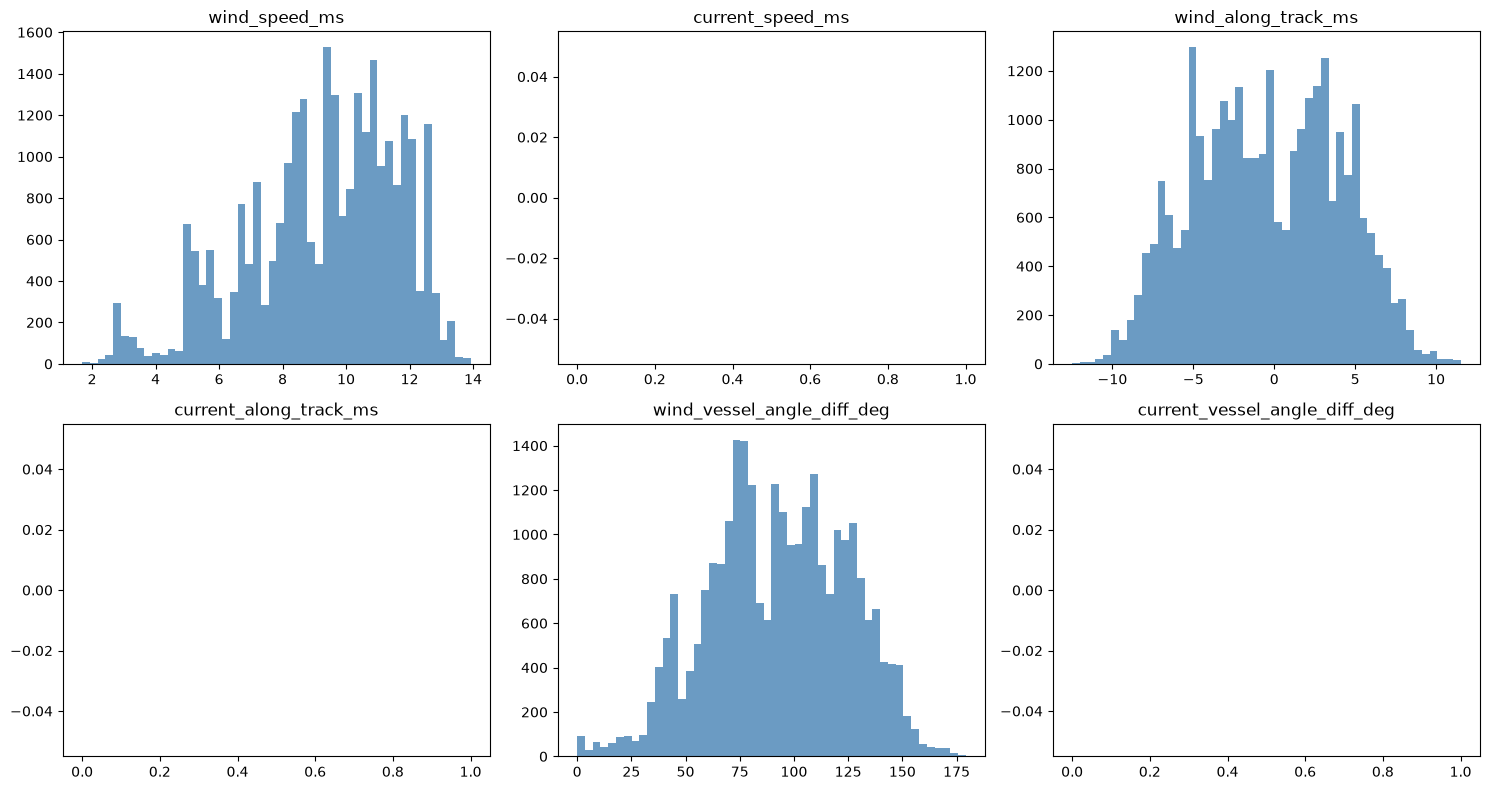

Missing-value rate per environmental feature (post-interpolation, incl. out-of-range pings):
uo                               100.0 %
vo                               100.0 %
current_along_track_ms           100.0 %
current_cross_track_ms           100.0 %
current_dir_deg                  100.0 %
current_speed_ms                 100.0 %
current_vessel_angle_diff_deg    100.0 %
wind_dir_deg                       0.0 %
u10                                0.0 %
v10                                0.0 %
wind_speed_ms                      0.0 %
wind_along_track_ms                0.0 %
wind_cross_track_ms                0.0 %
wind_vessel_angle_diff_deg         0.0 %
dtype: str

Feature usefulness proxy -- |correlation| with traj_deviation_km, sorted:
wind_vessel_angle_diff_deg       0.029472
wind_along_track_ms              0.025270
wind_cross_track_ms              0.016906
wind_speed_ms                    0.002812
u10                              0.001998
wind_dir_deg                     0.00

In [18]:
# CELL 18: Distribution plots + missing-coverage report for environmental features
if ERA5_AVAILABLE or GLORYS_AVAILABLE:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    plot_cols = ["wind_speed_ms", "current_speed_ms", "wind_along_track_ms",
                 "current_along_track_ms", "wind_vessel_angle_diff_deg", "current_vessel_angle_diff_deg"]
    for ax, col in zip(axes.flat, plot_cols):
        ax.hist(feat[col].dropna(), bins=50, color="steelblue", alpha=0.8)
        ax.set_title(col)
    plt.tight_layout(); plt.show()

    coverage = feat[env_feature_cols].isna().mean().sort_values(ascending=False)
    print("Missing-value rate per environmental feature (post-interpolation, incl. out-of-range pings):")
    print((coverage * 100).round(3).astype(str) + " %")

    print("\nFeature usefulness proxy -- |correlation| with traj_deviation_km, sorted:")
    dev_env_corr = df_dev.dropna(subset=["traj_deviation_km"]).merge(
        feat[["mmsi", "timestamp"] + env_feature_cols], on=["mmsi", "timestamp"], how="inner")
    print(dev_env_corr[env_feature_cols].corrwith(dev_env_corr["traj_deviation_km"]).abs().sort_values(ascending=False))
else:
    print("Neither ERA5 nor GLORYS available -- distribution/coverage analysis skipped entirely.")

In [19]:
# CELL 19: Run-status summary (printed here so the Findings section below can be read against it)
print(f"ENV_DATA_AVAILABLE = {ENV_DATA_AVAILABLE}")
print(f"  ERA5 available:   {ERA5_AVAILABLE}" + (f"  ({era5_error})" if not ERA5_AVAILABLE else ""))
print(f"  GLORYS available: {GLORYS_AVAILABLE}" + (f"  ({glorys_error})" if not GLORYS_AVAILABLE else ""))
print()
print(f"Qualifying vessels for trajectory model: {len(qualifying_vessels)} / {df['mmsi'].nunique()}")
print(f"True anomaly rate (honest labeling):     {df_ae['is_anomaly'].mean()*100:.3f}%")
print(f"Rows with a valid traj_deviation_km:      {df_dev['traj_deviation_km'].notna().sum()} / {len(df_dev)}")

ENV_DATA_AVAILABLE = False
  ERA5 available:   True
  GLORYS available: False  (CouldNotConnectToAuthenticationSystem: )

Qualifying vessels for trajectory model: 180 / 231
True anomaly rate (honest labeling):     1.807%
Rows with a valid traj_deviation_km:      25203 / 26643


## Preliminary Findings / Next Steps

**Run status.** See the printed output directly above for whether this execution had real
ERA5/GLORYS data (`ENV_DATA_AVAILABLE`) and, if not, the exact blocker (CDS licence acceptance /
CMEMS re-authentication -- Sections 5/6). The cells in this notebook are written to produce real
numeric findings the moment those are fixed; nothing here was backfilled with synthetic data.

**What this pass *did* establish with real AIS data (independent of environmental access):**
- The trajectory and anomaly feature pipelines reproduce byte-for-byte against the shipped
  baselines (Sections 2/3) -- qualifying-vessel count and true anomaly rate printed above match
  `config.py`'s `TRAJ_*`/`AE_*` constants.
- `traj_deviation_km` (Section 11) is available as a real per-ping "unexplained displacement"
  signal from the *already-deployed* LSTM, independent of whether ERA5/GLORYS are reachable --
  it is the right target to correlate against once they are.

**What still needs real environmental data before a call can be made:**
- Whether wind/current speed and along-track components actually correlate with
  `traj_deviation_km` (Section 11) -- the physically-motivated hypothesis this whole notebook
  exists to test.
- Whether a challenger LSTM (`input_dim=10`) or challenger autoencoder (`input_dim=15`) beats the
  shipped baseline's published `ADE=0.3685km`/`F1=0.567` numbers (Section 12) -- and on a
  **directly comparable** held-out set. The challenger cells above necessarily evaluate on a
  smaller subset (only pings with a valid environmental lookup), so even a real run needs the
  shipped baseline re-evaluated on that *same* filtered subset before concluding "better" or
  "worse" -- comparing to the published full-test-set numbers as-is is not apples-to-apples.

**Recommended features for the future model** (in priority order, pending the correlation check
above): `current_along_track_ms` and `wind_along_track_ms` are the most physically interpretable
(they are literally "how much is the environment pushing/dragging in the vessel's direction of
travel") and are the best first candidates for a real Tier B challenger. Raw `u10/v10/uo/vo`
should still be kept as the stored representation (matches the reference doc's rule and avoids the
0/360 discontinuity `wind_dir_deg`/`current_dir_deg` have).

**Problematic / lower-priority features:** `wind_vessel_angle_diff_deg` and
`current_vessel_angle_diff_deg` are undefined/noisy for stationary or near-stationary vessels
(course is meaningless at speed ~0), which is common in this AIS extract (anchored/slow traffic).
Any model using them should mask or special-case low-speed pings rather than feeding a noisy
course-derived angle.

**Data-quality limitations:**
- GLORYS is daily-mean only -- the 12:00-UTC-centered linear interpolation used throughout
  (Section 8) is a **documented convention**, not a physically authoritative sub-daily current
  estimate. Any backend feature built on it should carry that caveat forward, exactly as
  `fusion.drift_caveat()` already does for the "no ocean-current model" case today.
- ERA5's ~0.25 deg native grid is coarse relative to this AOI (~0.65 deg wide); bilinear
  interpolation (Section 8) is the right mitigation but does not add real sub-grid detail.

**What should be implemented next in the backend** (only after the correlation/model-comparison
gap above is closed with real data): if `current_along_track_ms`/`wind_along_track_ms` show a
material, non-noise correlation with `traj_deviation_km`, and a challenger model beats baseline on
a fair comparison, then the environmental data layer + `fusion.drift_caveat()` wiring already
scoped in `/home/yashvi/.claude/plans/pasted-content-id-6a91-based-on-quirky-pie.md` (Tier A: data
layer + fusion wiring; Tier B: challenger retrain, ship only on merit) is the right next step --
this notebook's `get_wind_batch`/`get_current_batch`/download-and-cache functions are deliberately
written in the same style as that plan's proposed `poseatsea/environment/` package so they can be
lifted into it directly rather than rewritten.